<a href="https://colab.research.google.com/github/tanish19078/tomato-disease-detector/blob/main/resnettomato.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121 -q

import torch
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")


PyTorch: 2.10.0+cu128
CUDA available: True
Device: Tesla T4


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs("/content/dataset", exist_ok=True)

# Copy dataset from Drive shortcut
!cp -r "/content/drive/MyDrive/Tomato_Caption"/* /content/dataset/

# Verify
for d in sorted(os.listdir("/content/dataset")):
    full = os.path.join("/content/dataset", d)
    if os.path.isdir(full):
        print(f"  {d}: {len(os.listdir(full))} images")


Mounted at /content/drive
  Tomato___Bacterial_spot: 2624 images
  Tomato___Early_blight: 2408 images
  Tomato___Late_blight: 2616 images
  Tomato___Septoria_leaf_spot: 2392 images
  Tomato___healthy: 3789 images


PyTorch Version: 2.10.0+cu128
Using Device: cuda
Dataset directory already exists. Skipping extraction.
Classes: ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Septoria_leaf_spot', 'Tomato___healthy']
Splits: {'train': 11063, 'val': 1382, 'test': 1384}
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 191MB/s]


Epoch 1/25
------------------------------
  train Loss: 0.9152  Acc: 0.7479
  val   Loss: 0.5754  Acc: 0.9124
  *** New best val acc: 0.9124 ***

Epoch 2/25
------------------------------
  train Loss: 0.7378  Acc: 0.8497
  val   Loss: 0.5080  Acc: 0.9573
  *** New best val acc: 0.9573 ***

Epoch 3/25
------------------------------
  train Loss: 0.6815  Acc: 0.8738
  val   Loss: 0.4773  Acc: 0.9595
  *** New best val acc: 0.9595 ***

Epoch 4/25
------------------------------
  train Loss: 0.6826  Acc: 0.8731
  val   Loss: 0.4643  Acc: 0.9638
  *** New best val acc: 0.9638 ***

Epoch 5/25
------------------------------
  train Loss: 0.6582  Acc: 0.8817
  val   Loss: 0.4580  Acc: 0.9667
  *** New best val acc: 0.9667 ***

Epoch 6/25
------------------------------
  train Loss: 0.7217  Acc: 0.8530
  val   Loss: 0.4951  Acc: 0.9580

Epoch 7/25
------------------------------
  train Loss: 0.6764  Acc: 0.8760
  val   Loss: 0.4801  Acc: 0.9602

Epoch 8/25
------------------------------
  trai

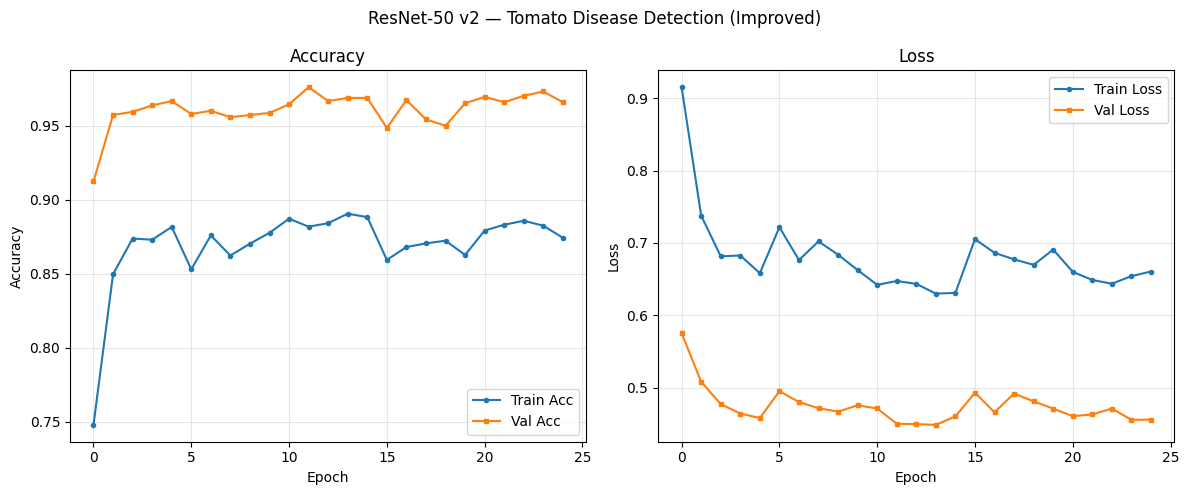

Saved training curves plot.

Overall Test Accuracy: 0.9805 (1357/1384)

── Per-Class Test Accuracy ──
  Tomato___Bacterial_spot                   1.0000  (264/264)
  Tomato___Early_blight                     0.9221  (213/231)
  Tomato___Late_blight                      1.0000  (264/264)
  Tomato___Septoria_leaf_spot               0.9653  (250/259)
  Tomato___healthy                          1.0000  (366/366)

── Confusion Matrix ──
        Bact  EBli  LBli  Sept  Hlth
  Bact   264     0     0     0     0
  EBli     3   213     0    15     0
  LBli     0     0   264     0     0
  Sept     0     9     0   250     0
  Hlth     0     0     0     0   366


ModuleNotFoundError: No module named 'onnxscript'

In [ ]:
"""
Tomato Leaf Disease Detection — ResNet-50 Training Script (v2 — Improved)
==========================================================================
Improvements over v1:
  - Stronger augmentation: RandomAffine, RandomPerspective, GaussianBlur
  - Label smoothing (0.1) to reduce overconfidence
  - CosineAnnealingWarmRestarts scheduler for better convergence
  - 25 epochs (up from 15)
  - Mixup augmentation to improve generalization on confusable classes
  - Per-class accuracy reporting to catch Septoria/Early Blight confusion
  - Confusion matrix at the end

Run on Google Colab with T4 GPU:
  1. Upload the 5 zip files to /content/
  2. Run this script
  3. Download the .onnx, .onnx.data, and class_mapping_resnet.json files
"""

import os
import time
import copy
import json
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import DataLoader, random_split, Dataset
import torchvision
from torchvision import datasets, transforms, models

print("PyTorch Version:", torch.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:", device)


# ─── 1. Dataset Setup ────────────────────────────────────────────────────

class TransformSubset(Dataset):
    """
    Wraps a torch.utils.data.Subset with a custom transform.
    This avoids the bug where setting .dataset.transform mutates
    the shared parent dataset for ALL subsets.
    """
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        raw_img_path, label = self.subset.dataset.samples[self.subset.indices[index]]
        from PIL import Image
        img = Image.open(raw_img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label

    def __len__(self):
        return len(self.subset)


# Unzip data if needed
data_dir = "/content/dataset"
if not os.path.exists(data_dir):
    import glob, zipfile
    os.makedirs(data_dir)
    print("Unzipping dataset files...")
    for zip_file in glob.glob("/content/*.zip"):
        print(f"  Extracting {zip_file}...")
        with zipfile.ZipFile(zip_file, 'r') as zip_ref:
            zip_ref.extractall(data_dir)
    print("Finished unzipping!")
else:
    print("Dataset directory already exists. Skipping extraction.")


input_size = 224
batch_size = 32

# ── STRONGER augmentation pipeline ──────────────────────────────────────
train_transform = transforms.Compose([
    transforms.Resize((input_size, input_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(20),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.RandomPerspective(distortion_scale=0.15, p=0.3),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.15, hue=0.05),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.15)),
])

val_transform = transforms.Compose([
    transforms.Resize((input_size, input_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load dataset WITHOUT transform — raw images
full_dataset = datasets.ImageFolder(data_dir, transform=None)

# 80/10/10 split
total_len = len(full_dataset)
train_len = int(0.8 * total_len)
val_len = int(0.1 * total_len)
test_len = total_len - train_len - val_len

train_subset, val_subset, test_subset = random_split(
    full_dataset,
    [train_len, val_len, test_len],
    generator=torch.Generator().manual_seed(42)
)

train_data = TransformSubset(train_subset, train_transform)
val_data = TransformSubset(val_subset, val_transform)
test_data = TransformSubset(test_subset, val_transform)

dataloaders = {
    'train': DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True),
    'val': DataLoader(val_data, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True),
    'test': DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
}
dataset_sizes = {'train': len(train_data), 'val': len(val_data), 'test': len(test_data)}
class_names = full_dataset.classes
num_classes = len(class_names)

print(f"Classes: {class_names}")
print(f"Splits: {dataset_sizes}")


# ─── 2. Mixup Augmentation ──────────────────────────────────────────────

def mixup_data(x, y, alpha=0.2):
    """Mixup: creates virtual training examples by blending pairs of images."""
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1.0
    batch_size = x.size(0)
    index = torch.randperm(batch_size).to(x.device)
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam


def mixup_criterion(criterion, pred, y_a, y_b, lam):
    """Compute mixup loss."""
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)


# ─── 3. Model Definition ─────────────────────────────────────────────────

def initialize_model(num_classes, feature_extract=False):
    model_ft = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

    if feature_extract:
        for param in model_ft.parameters():
            param.requires_grad = False

    num_ftrs = model_ft.fc.in_features
    model_ft.fc = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(num_ftrs, num_classes)
    )
    return model_ft


model_ft = initialize_model(num_classes=num_classes, feature_extract=False)
model_ft = model_ft.to(device)


# ─── 4. Training Configuration ───────────────────────────────────────────

optimizer_ft = optim.AdamW(model_ft.parameters(), lr=3e-4, weight_decay=1e-4)

# Label smoothing to reduce overconfidence
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# Cosine annealing for smoother learning rate decay
NUM_EPOCHS = 25
scheduler = lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer_ft, T_0=5, T_mult=2, eta_min=1e-6
)


# ─── 5. Training Loop ────────────────────────────────────────────────────

def train_model(model, dataloaders, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()
    val_acc_history = []
    train_acc_history = []
    train_loss_history = []
    val_loss_history = []

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    use_mixup = True

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 30)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    if phase == 'train' and use_mixup:
                        mixed_inputs, targets_a, targets_b, lam = mixup_data(inputs, labels, alpha=0.2)
                        outputs = model(mixed_inputs)
                        loss = mixup_criterion(criterion, outputs, targets_a, targets_b, lam)
                        _, preds = torch.max(outputs, 1)
                        # For accuracy, count based on the dominant target
                        running_corrects += (lam * torch.sum(preds == targets_a.data)
                                           + (1 - lam) * torch.sum(preds == targets_b.data))
                    else:
                        outputs = model(inputs)
                        loss = criterion(outputs, labels)
                        _, preds = torch.max(outputs, 1)
                        running_corrects += torch.sum(preds == labels.data)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)

            if phase == 'train':
                scheduler.step(epoch + 1)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            if phase == 'train':
                train_acc_history.append(epoch_acc.item())
                train_loss_history.append(epoch_loss)
            else:
                val_acc_history.append(epoch_acc.item())
                val_loss_history.append(epoch_loss)

            print(f'  {phase:5s} Loss: {epoch_loss:.4f}  Acc: {epoch_acc:.4f}')

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                print(f'  *** New best val acc: {best_acc:.4f} ***')
        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:.4f}')

    model.load_state_dict(best_model_wts)
    return model, train_acc_history, val_acc_history, train_loss_history, val_loss_history


model_ft, t_acc, v_acc, t_loss, v_loss = train_model(
    model_ft, dataloaders, criterion, optimizer_ft, scheduler, num_epochs=NUM_EPOCHS
)

torch.save(model_ft.state_dict(), "best_resnet50_tomato.pth")
print("Saved best_resnet50_tomato.pth")


# ─── 6. Plot Training Curves ─────────────────────────────────────────────

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(t_acc, label="Train Acc", marker='o', markersize=3)
plt.plot(v_acc, label="Val Acc", marker='s', markersize=3)
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(t_loss, label="Train Loss", marker='o', markersize=3)
plt.plot(v_loss, label="Val Loss", marker='s', markersize=3)
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.suptitle("ResNet-50 v2 — Tomato Disease Detection (Improved)")
plt.tight_layout()
plt.savefig("resnet50_training_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved training curves plot.")


# ─── 7. Test Set Evaluation + Per-Class Accuracy ─────────────────────────

model_ft.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in dataloaders['test']:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model_ft(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

test_acc = np.mean(all_preds == all_labels)
print(f"\nOverall Test Accuracy: {test_acc:.4f} ({np.sum(all_preds == all_labels)}/{len(all_labels)})")

# Per-class accuracy
print("\n── Per-Class Test Accuracy ──")
for i, cls in enumerate(class_names):
    mask = all_labels == i
    if mask.sum() == 0:
        continue
    cls_acc = np.mean(all_preds[mask] == i)
    cls_total = mask.sum()
    cls_correct = np.sum(all_preds[mask] == i)
    print(f"  {cls:40s}  {cls_acc:.4f}  ({cls_correct}/{cls_total})")

# Confusion matrix
print("\n── Confusion Matrix ──")
short = ['Bact', 'EBli', 'LBli', 'Sept', 'Hlth']
print(f"{'':>6}", end='')
for s in short:
    print(f"{s:>6}", end='')
print()
for i, cls in enumerate(class_names):
    print(f"{short[i]:>6}", end='')
    for j in range(num_classes):
        count = np.sum((all_labels == i) & (all_preds == j))
        print(f"{count:>6}", end='')
    print()


# ─── 8. ONNX Export ──────────────────────────────────────────────────────

model_ft.eval()
model_ft_cpu = model_ft.cpu()
dummy_input = torch.randn(1, 3, 224, 224)

torch.onnx.export(
    model_ft_cpu,
    dummy_input,
    "tomato_disease_resnet50.onnx",
    export_params=True,
    opset_version=18,
    do_constant_folding=True,
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}}
)

# Save class mapping
with open("class_mapping_resnet.json", "w") as f:
    json.dump({k: v for k, v in enumerate(class_names)}, f)

print("\nExported to ONNX successfully!")
print("Files to download:")
print("  - tomato_disease_resnet50.onnx")
print("  - tomato_disease_resnet50.onnx.data")
print("  - class_mapping_resnet.json")
print("  - best_resnet50_tomato.pth")
print("  - resnet50_training_curves.png")


In [ ]:
# Re-run ONNX export (onnxscript is now installed)
model_ft.eval()
model_ft_cpu = model_ft.cpu()
dummy_input = torch.randn(1, 3, 224, 224)

torch.onnx.export(
    model_ft_cpu,
    dummy_input,
    "tomato_disease_resnet50.onnx",
    export_params=True,
    opset_version=18,
    do_constant_folding=True,
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}}
)
print("ONNX export done!")


/tmp/ipykernel_1432/3366618198.py:6: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0428 10:23:37.150000 1432 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0428 10:23:37.154000 1432 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'rois' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0428 10:23:37.155000 1432 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: '

[torch.onnx] Obtain model graph for `ResNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ResNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
ONNX export done!


In [ ]:
import json

# Create the class mapping file
with open("class_mapping_resnet.json", "w") as f:
    json.dump({k: v for k, v in enumerate(class_names)}, f)

print("Created class_mapping_resnet.json")

# Download remaining files
from google.colab import files
files.download("class_mapping_resnet.json")
files.download("best_resnet50_tomato.pth")
files.download("resnet50_training_curves.png")


Created class_mapping_resnet.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>